In [1]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
# import os
# import tensorflow as tf
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg

# # 1. Check for GPU
# print("System Status:")
# if tf.config.list_physical_devices('GPU'):
#     print("✅ GPU is detected and ready!")
# else:
#     print("❌ GPU is NOT detected. Please enable it in Settings.")

# # 2. Define the dataset path (Kaggle standard path)
# base_path = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/'

# # # 3. Check directory structurefrom tensorflow.keras.preprocessing.image import ImageDataGenerator

# # 1. Define Basic Parameters
# IMG_WIDTH, IMG_HEIGHT = 224, 224  # Standard size for neural networks
# BATCH_SIZE = 32

# # 2. Create the Generators (Rescaling pixel values from 0-255 to 0-1)
# train_datagen = ImageDataGenerator(rescale=1./255)
# val_datagen = ImageDataGenerator(rescale=1./255)
# test_datagen = ImageDataGenerator(rescale=1./255)

# # 3. Link Generators to the Folders
# print("Loading Training Data:")
# train_generator = train_datagen.flow_from_directory(
#     '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/',
#     target_size=(IMG_WIDTH, IMG_HEIGHT),
#     batch_size=BATCH_SIZE,
#     class_mode='binary',
#     shuffle=True
# )

# print("\nLoading Validation Data:")
# val_generator = val_datagen.flow_from_directory(
#     '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/',
#     target_size=(IMG_WIDTH, IMG_HEIGHT),
#     batch_size=BATCH_SIZE,
#     class_mode='binary',
#     shuffle=False
# )

# print("\nLoading Test Data:")
# test_generator = test_datagen.flow_from_directory(
#     '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/',
#     target_size=(IMG_WIDTH, IMG_HEIGHT),
#     batch_size=BATCH_SIZE,
#     class_mode='binary',
#     shuffle=False
# )
# # print("\nDataset Content:")
# # for root, dirs, files in os.walk(base_path):
# #     if not dirs: # Only print leaf directories to save space
# #         print(f"Found {len(files)} images in {root}")


import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Check for GPU
print("System Status:")
if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is detected and ready!")
else:
    print("❌ GPU is NOT detected. Please enable it in Settings.")

# 2. Define Basic Parameters
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

# 3. Create the Generators (CORRECTED: NO RESCALING)
# We removed "rescale=1./255" so the model sees the actual image colors.
train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

# 4. Link Generators to the Folders
print("\nLoading Training Data (Raw Values):")
train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

print("\nLoading Validation Data:")
val_generator = val_datagen.flow_from_directory(
    '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nLoading Test Data:")
test_generator = test_datagen.flow_from_directory(
    '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

System Status:
✅ GPU is detected and ready!

Loading Training Data (Raw Values):
Found 100000 images belonging to 2 classes.

Loading Validation Data:
Found 20000 images belonging to 2 classes.

Loading Test Data:
Found 20000 images belonging to 2 classes.


Found Real File: 64601.jpg
Found Fake File: H7PRNYG8IN.jpg


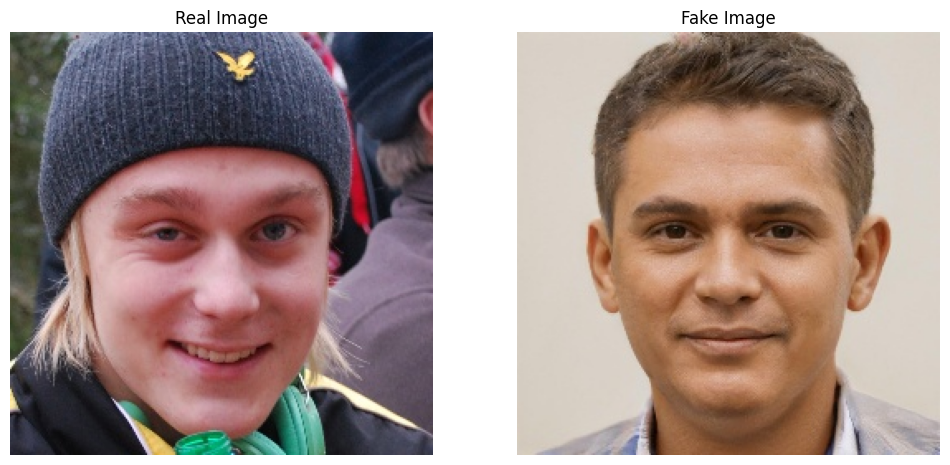

In [4]:
# Define the training directories
real_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real'
fake_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/fake'

# Dynamically get the first available file in each folder
real_filename = os.listdir(real_dir)[0]
fake_filename = os.listdir(fake_dir)[0]

print(f"Found Real File: {real_filename}")
print(f"Found Fake File: {fake_filename}")

# Build the full paths
real_img_path = os.path.join(real_dir, real_filename)
fake_img_path = os.path.join(fake_dir, fake_filename)

# Display them
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(mpimg.imread(real_img_path))
ax[0].set_title("Real Image")
ax[0].axis('off')

ax[1].imshow(mpimg.imread(fake_img_path))
ax[1].set_title("Fake Image")
ax[1].axis('off')

plt.show()

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define Basic Parameters
IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32

# 2. Create the Generators (NO RESCALE for EfficientNet!)
# We removed "rescale=1./255" because EfficientNet expects 0-255 values.
train_datagen = ImageDataGenerator()
val_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

# 3. Link Generators to the Folders
print("Loading Training Data (Raw Pixel Values):")
train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

print("\nLoading Validation Data:")
val_generator = val_datagen.flow_from_directory(
    '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\nLoading Test Data:")
test_generator = test_datagen.flow_from_directory(
    '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Loading Training Data (Raw Pixel Values):
Found 100000 images belonging to 2 classes.

Loading Validation Data:
Found 20000 images belonging to 2 classes.

Loading Test Data:
Found 20000 images belonging to 2 classes.


In [6]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# 1. Load the Pre-trained Base Model (EfficientNetB0)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze the Base Model
base_model.trainable = False

# 3. Add Our Custom Layers (The new "Head")
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

# 4. Construct the Final Model
model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile the Model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("✅ Model built and compiled successfully!")

I0000 00:00:1771399293.291830     336 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771399293.297114     336 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✅ Model built and compiled successfully!


In [ ]:
# Heavy Training DO NOT RUN


# from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# # 1. Define Callbacks
# # Save the best model only (if validation loss improves)
# checkpoint = ModelCheckpoint(
#     'best_deepfake_model.keras', 
#     monitor='val_loss', 
#     save_best_only=True, 
#     mode='min', 
#     verbose=1
# )

# # Stop early if the model stops improving for 3 epochs (prevents wasting time)
# early_stopping = EarlyStopping(
#     monitor='val_loss', 
#     patience=3, 
#     restore_best_weights=True
# )

# # 2. Start Training
# print("🚀 Starting Training...")
# history = model.fit(
#     train_generator,
#     epochs=10,
#     validation_data=val_generator,
#     callbacks=[checkpoint, early_stopping]
# )

# print("✅ Training Complete!")

In [8]:
# 1. IMPORT THE MISSING TOOLS
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 2. Calculate a smaller number of steps (Fast Track)
fast_train_steps = len(train_generator) // 5
fast_val_steps = len(val_generator) // 5

print(f"🚀 Training on {fast_train_steps} batches per epoch")

# 3. Define Callbacks
checkpoint = ModelCheckpoint(
    'best_deepfake_model.keras', 
    monitor='val_loss', 
    save_best_only=True, 
    mode='min', 
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True
)

# 4. Start Fast Training
history = model.fit(
    train_generator,
    steps_per_epoch=fast_train_steps,
    validation_steps=fast_val_steps,
    epochs=10,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stopping]
)

print("✅ Training Complete!")

🚀 Training on 625 batches per epoch
Epoch 1/10


I0000 00:00:1771399430.250487     449 service.cc:152] XLA service 0x7955c01136f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771399430.250523     449 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771399430.250527     449 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771399432.417483     449 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-18 07:23:58.524496: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 07:23:58.668877: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 07:23:59.013103: E external/local_xl

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6943 - loss: 0.5807
Epoch 1: val_loss improved from inf to 0.33230, saving model to best_deepfake_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 111ms/step - accuracy: 0.6944 - loss: 0.5806 - val_accuracy: 0.8823 - val_loss: 0.3323
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7951 - loss: 0.4461
Epoch 2: val_loss improved from 0.33230 to 0.31149, saving model to best_deepfake_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 106ms/step - accuracy: 0.7951 - loss: 0.4461 - val_accuracy: 0.8850 - val_loss: 0.3115
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8123 - loss: 0.4100
Epoch 3: val_loss did not improve from 0.31149
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 121ms/step - accuracy: 0.8124 - loss: 0.4100 - val_accuracy: 0.8792 - val_loss: 0.3224
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8302 - loss: 0.3836
Epoch 4: val_loss improved from 0.31149 to 0.26104, saving model to be

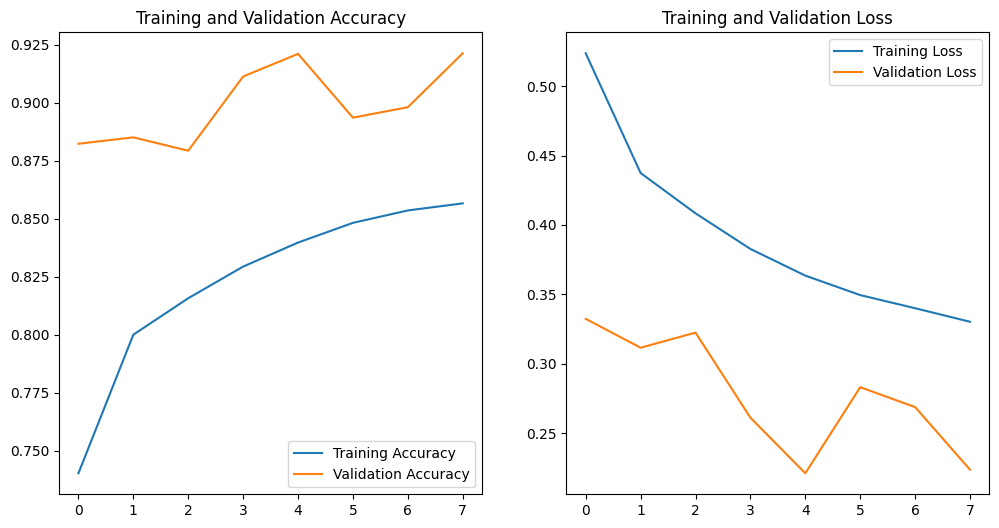

In [9]:
import matplotlib.pyplot as plt

# 1. Extract the data from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

# 2. Plot Training vs Validation Accuracy
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# 3. Plot Training vs Validation Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [10]:
# 1. Load the Best Saved Model
# We reload the model from the checkpoint to ensure we use the absolute best version
# (the one from Epoch 5 or 8 that had the lowest loss), not just the final state.
model.load_weights('best_deepfake_model.keras')

# 2. Run Evaluation on Test Data
print("🚀 Running Final Test Evaluation...")
test_loss, test_acc = model.evaluate(test_generator)

print("\n" + "="*30)
print(f"🏆 FINAL PROJECT ACCURACY: {test_acc * 100:.2f}%")
print("="*30)

🚀 Running Final Test Evaluation...
625/625 ━━━━━━━━━━━━━━━━━━━━ 230s 369ms/step - accuracy: 0.8924 - loss: 0.2654

🏆 FINAL PROJECT ACCURACY: 83.71%


Testing file: KMBC02XSYH.jpg


2026-02-18 07:46:28.807558: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 07:46:28.942651: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 07:46:29.643375: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 07:46:29.778791: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
✅ REAL FACE. (Confidence: 0.97)


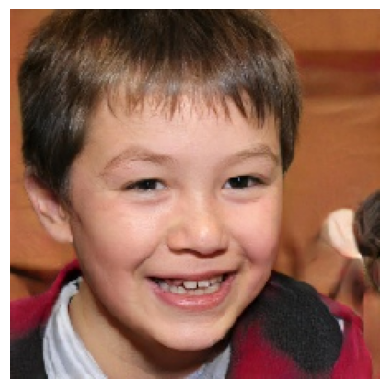

In [11]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(image_path):
    # 1. Load and Resize the Image
    # We must match the input shape (224x224) we defined in Step 4
    img = image.load_img(image_path, target_size=(224, 224))
    
    # 2. Convert to Array
    # This turns the image into numbers (height, width, channels)
    img_array = image.img_to_array(img)
    
    # 3. Add Batch Dimension
    # The model expects a batch of images (1, 224, 224, 3), not just one image.
    img_array = np.expand_dims(img_array, axis=0)
    
    # 4. Get Prediction
    # The model outputs a number between 0 and 1
    prediction = model.predict(img_array)[0][0]
    
    # 5. Interpret Result
    # < 0.5 means the model thinks it's REAL (Class 0)
    # > 0.5 means the model thinks it's FAKE (Class 1)
    if prediction > 0.5:
        print(f"🛑 FAKE DETECTED! (Confidence: {prediction:.2f})")
    else:
        print(f"✅ REAL FACE. (Confidence: {1 - prediction:.2f})")
        
    # Show the image so we can judge it ourselves
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# --- TEST IT NOW ---
# Let's test it on a random image from the dataset to make sure the function works
import random
import os

# Pick a random file from the "Fake" test folder
test_fake_dir = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/test/fake/'
random_file = random.choice(os.listdir(test_fake_dir))
file_path = os.path.join(test_fake_dir, random_file)

print(f"Testing file: {random_file}")
predict_image(file_path)

In [12]:
import cv2  # OpenCV for video processing
import numpy as np

def predict_video(video_path):
    print(f"PROCESSING VIDEO: {video_path}")
    
    # 1. Open the Video
    cap = cv2.VideoCapture(video_path)
    
    frames = []
    frame_count = 0
    
    # 2. Loop through the video frame by frame
    while True:
        ret, frame = cap.read()
        
        # If no frame is returned, the video is finished
        if not ret:
            break
            
        # 3. Process every 30th frame (approx. 1 per second)
        # This speeds up prediction by 30x without losing much accuracy
        if frame_count % 30 == 0:
            # OpenCV reads colors as BGR, but our model expects RGB. Fix it:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Resize to the model's required shape (224x224)
            frame = cv2.resize(frame, (224, 224))
            
            # Add to our list of frames to check
            frames.append(frame)
            
        frame_count += 1
        
    cap.release()
    
    if len(frames) == 0:
        print("Error: Could not read video. Check the path.")
        return

    # 4. Convert list of frames to a numpy array (Batch)
    # Shape becomes: (Number_of_Frames, 224, 224, 3)
    video_batch = np.array(frames)
    
    # 5. Predict on all frames at once
    print(f"Analyzing {len(frames)} frames...")
    predictions = model.predict(video_batch)
    
    # 6. Average the results
    # If the average is > 0.5, it's mostly Fake. If < 0.5, it's mostly Real.
    avg_score = np.mean(predictions)
    
    print("\n" + "="*30)
    if avg_score > 0.5:
        print(f"🛑 DEEPFAKE DETECTED!")
        print(f"Confidence: {avg_score * 100:.2f}% Fake")
    else:
        print(f"✅ REAL VIDEO DETECTED.")
        print(f"Confidence: {(1 - avg_score) * 100:.2f}% Real")
    print("="*30)

print("Video Processor Ready!")

Video Processor Ready!


In [13]:
# REPLACE THIS PATH with the one you just copied
my_video_path = "/kaggle/input/datasets/sujaldixit397/test-vid/WIN_20260218_13_23_00_Pro.mp4" 

# Run the detector!
predict_video(my_video_path)

PROCESSING VIDEO: /kaggle/input/datasets/sujaldixit397/test-vid/WIN_20260218_13_23_00_Pro.mp4
Analyzing 2 frames...


2026-02-18 07:57:41.775098: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 07:57:41.909020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 07:57:42.207987: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 07:57:42.348215: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 07:57:43.027863: E external/local_xla/xla/stream_

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step

🛑 DEEPFAKE DETECTED!
Confidence: 61.78% Fake


In [ ]:
# 1. Install Gradio (The UI builder)
# We use -q to keep the output clean
!pip install -q gradio

import gradio as gr
import cv2
import numpy as np
import tensorflow as tf

# Load the model explicitly just to be safe
model = tf.keras.models.load_model('best_deepfake_model.keras')

# 2. Define the "Brain" of the App
def scan_video(video_file):
    if video_file is None:
        return "Please upload a video file."
        
    cap = cv2.VideoCapture(video_file)
    frames = []
    frame_count = 0
    
    # Process 1 frame every second (approx 30 frames)
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        if frame_count % 30 == 0:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (224, 224))
            frames.append(frame)
        frame_count += 1
    cap.release()
    
    if len(frames) == 0:
        return "Error: Could not read video."

    # Prediction
    video_batch = np.array(frames)
    predictions = model.predict(video_batch)
    
    # Averages the results
    avg_score = np.mean(predictions)
    
    # Return a clean result string
    if avg_score > 0.5:
        return f"🛑 FAKE DETECTED!\nConfidence: {avg_score * 100:.1f}%"
    else:
        return f"✅ REAL VIDEO.\nConfidence: {(1 - avg_score) * 100:.1f}%"

# 3. Create the Interface
interface = gr.Interface(
    fn=scan_video,  # The function to run
    inputs=gr.Video(), # The input box (Video uploader)
    outputs="text",    # The output box (Result text)
    title="🕵️‍♂️ Deepfake Detector AI",
    description="Upload a video to check if it's Real or Fake."
)

# 4. Launch the App
print("🚀 Launching App...")
interface.launch(share=True, debug=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.8/444.8 kB 8.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.2 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
langchain-core 0.3.79 requires packaging<26.0.0,>=23.2.0, but you have packaging 26.0rc2 which is incompatible.
fastai 2.8.4 requires fastcore<1.9,>=1.8.0, but you have fastcore 1.11.3 which is incompatible.
🚀 Launching App...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://dd9b391e2052442f1e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to dep